In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("Mall_Customers.xls")
print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0


In [24]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [32]:
df = df.dropna()

In [33]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X = X.dropna()

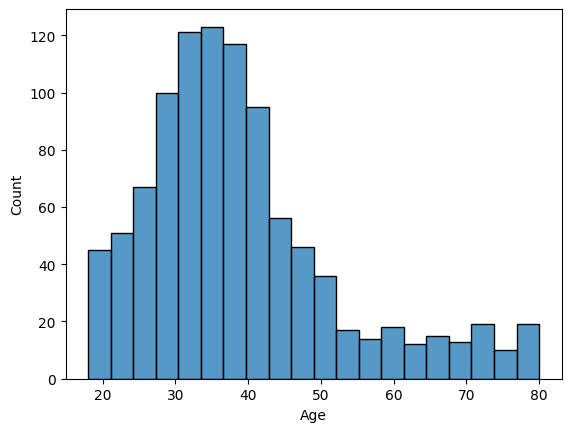

In [5]:
sns.histplot(df['Age'], bins=20)
plt.show()

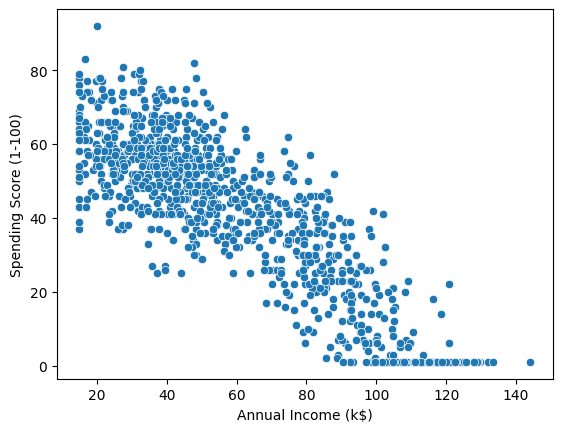

In [25]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.show()

In [26]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

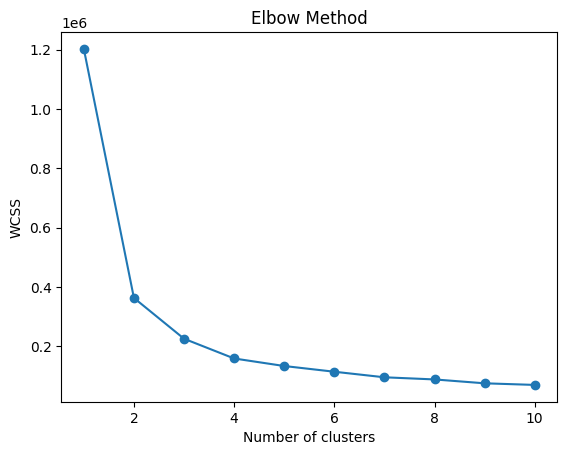

In [34]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [35]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

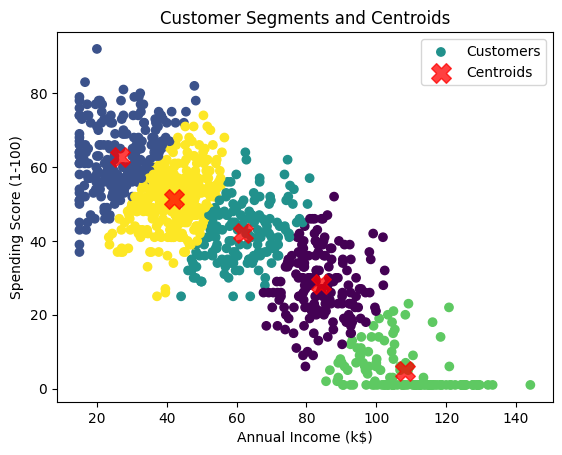

In [36]:
# Visualize the clusters and centroids for KMeans
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=y_kmeans, cmap='viridis', label='Customers')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments and Centroids')
plt.legend()
plt.show()